# Modèle de prévision du nombre de nouveaux cas de VIH

Dans cette partie, nous utiliserons les données historiques du programme national VIH, comprenant le nombre mensuel de nouveaux cas positifs. L’objectif est de développer un modèle de prévision capable d’estimer le nombre de nouveaux cas pour un mois donné, afin d’anticiper les tendances épidémiologiques et de renforcer la planification des actions de prévention et de dépistage. 

## Étape 1: Imporation des bibliothèques pour l'analyse des séries temporelles


In [1]:
#Importation des bibliothèques de base
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Importation des bibliothèques spécifiques aux séries chronologiques
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error



## Étape 2: Téléchargement de la base de données


In [7]:
# Load data
df_predict = pd.read_excel("df_predict.xlsx")
df_predict

,DATE_VIH,SEXE,AGE,FDR,Rslt_test_VIH,Année,Mois,Jour,Trimestre
0,2018-11-21,F,51,Hétérosexuel,Positif,2018,novembre,21,4
1,2014-01-18,F,46,Hétérosexuel,Positif,2014,janvier,18,1
2,2010-06-15,H,16,materno-foetale,Positif,2010,juin,15,2
3,2011-06-15,H,11,materno-foetale,Positif,2011,juin,15,2
4,2014-10-01,H,34,MSM,Positif,2014,octobre,1,4
...,...,...,...,...,...,...,...,...,...
4806,2025-05-19,H,32,MSM,positif,2025,mai,19,2
4807,2025-04-24,H,57,MSM,positif,2025,avril,24,2
4808,2025-07-11,H,28,MSM,positif,2025,juillet,11,3
4809,2025-01-20,H,39,UDI,positif,2025,janvier,20,1


In [8]:
# S'assurer que la colonne DATE_VIH est au format datetime
df_predict["DATE_VIH"] = pd.to_datetime(df_predict["DATE_VIH"])

# Définir la colonne DATE_VIH comme index
df_predict.set_index("DATE_VIH", inplace=True)

# Agréger les données par mois (premier jour de chaque mois)
# Ici, on compte le nombre de cas par mois
df = df_predict.resample('MS').size().reset_index(name='Hiv_cases')

# Renommer la colonne de date en "Month"
df.rename(columns={"DATE_VIH": "Month"}, inplace=True)

# Afficher les premières lignes du DataFrame
print(df.head())

       Month  Hiv_cases
0 1984-01-01          1
1 1984-02-01          0
2 1984-03-01          0
3 1984-04-01          0
4 1984-05-01          0


In [9]:
df.set_index(df.columns[0], inplace=True)
print(df.head())

            Hiv_cases
Month                
1984-01-01          1
1984-02-01          0
1984-03-01          0
1984-04-01          0
1984-05-01          0


In [12]:
df.isna().sum()

Hiv_cases    0
dtype: int64

In [13]:
# Afficher des statistiques descriptives sur df avec arrondi à deux décimales
df.info()
print (df.describe().round(decimals=2))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 1984-01-01 to 2025-08-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Hiv_cases  500 non-null    int64
dtypes: int64(1)
memory usage: 7.8 KB
       Hiv_cases
count     500.00
mean        9.62
std        18.03
min         0.00
25%         0.00
50%         2.00
75%         8.25
max       139.00


On remarque que :

Le jeu de données contient 500 entrées allant du 1er janvier 1984 au 1er août 2025.
Il comprend une seule colonne intitulée "Hiv_cases", représentant le nombre mensuel de nouveaux cas de VIH, avec 500 valeurs non nulles.
Les statistiques descriptives montrent une moyenne de 9,62 cas par mois, avec un écart-type de 18,03, un minimum de 0 et un maximum de 139, indiquant une forte variabilité entre les périodes.

## Étape 3: Visualisation de la série temporelle


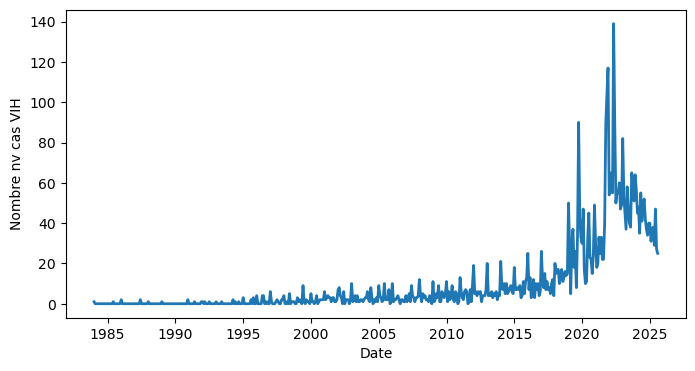

In [14]:
plt.figure(figsize = (8,4))               # Définir la taille de la figure
plt.plot(df,linewidth = 2)                # Tracer la série temporelle, avec linewidth=2 spécifie l'épaisseur de la ligne.
plt.xlabel('Date')                        # Ajouter une étiquette à l'axe des x (Date)
plt.ylabel('Nombre nv cas VIH')           # Ajouter une étiquette à l'axe des y (Nombre de passagers)
plt.show()                                # Afficher le graphique

D’après la figure ci-dessus, nous pouvons constater :

Une tendance générale à la hausse du nombre de nouveaux cas de VIH au fil des années, particulièrement marquée à partir des années 2010.
On observe également des fluctuations irrégulières pouvant être liées à des variations dans les campagnes de dépistage, la déclaration des cas ou d’autres facteurs contextuels, sans réelle saisonnalité apparente.

## Étape 4: Décomposition de la série temporelle pour voir les composantes (tendance, saisonnalité, bruit)


La bibliothèque **statsmodels** en Python offre des outils pour décomposer une série temporelle en ses composantes principales.

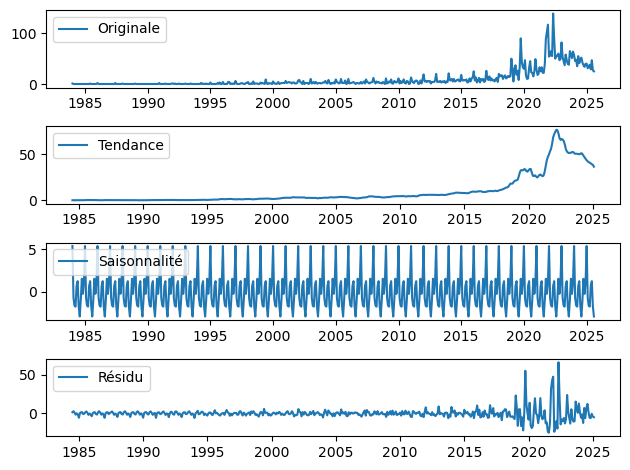

In [15]:
# Décomposition de la série temporelle avec un modèle multiplicatif
decomposition = seasonal_decompose(df, model="additive")

# Extraction des composantes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Affichage des composantes
plt.subplot(411)
plt.plot(df, label='Originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidu')
plt.legend(loc='upper left')
plt.tight_layout()

## Étape 5: Détection de la stationnarité


Analyse de la série temporelle (1985–2025)

La décomposition de la série temporelle met en évidence les caractéristiques suivantes :  

| Composante | Observation | Conséquence / Implication |
|------------|------------|---------------------------|
| **Originale** | Forte croissance, surtout après 2018, avec une volatilité qui augmente proportionnellement au niveau. | La série est fortement non-stationnaire et nécessite une transformation ou une différenciation pour certaines méthodes de prévision. |
| **Tendance** | La moyenne est très faible jusqu'en 2018, puis une nette augmentation se dessine avant de se stabiliser. | La moyenne n'est pas constante dans le temps, indiquant une tendance haussière significative après 2018. |
| **Saisonnalité** | Fluctuations régulières, mais d'amplitude relativement faible (±5) comparée à la tendance. | La saisonnalité est faible et a un impact limité sur la dynamique globale de la série. |
| **Résidu** | Le bruit ou l'irrégularité augmente fortement avec la tendance, surtout après 2018. | La variance n’est pas constante dans le temps, signalant un problème d’hétéroscédasticité qui pourrait influencer la qualité des préviMAX adaptés.

Une façon de vérifier la stationnarité d'une série temporelle :

***Test de Dickey Fuller***: il s'agit d'un test statistique permettant de vérifier la stationnarité des séries temporelles.
-- Hypothèse nulle (H0) : la série est non stationnaire.
-- Hypothèse alternative (H1) : la série est stationnaire.

* Si la p-value < à la valeur critique, alors on ***rejette*** l'hypothèse nulle (H0). Cela indique que la série temporelle est **stationnaire**.

In [16]:
print('-------------Résultats du Test Dickey Fuller-------------')

result = adfuller(df['Hiv_cases'], autolag='AIC')

# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Interpréter les résultats
if result[1] < 0.05:
    print('La série est stationnaire.')
else:
    print('La série est non-stationnaire.')


-------------Résultats du Test Dickey Fuller-------------
ADF Statistic: -1.545270
p-value: 0.511010
La série est non-stationnaire.


**Conclusion synthétique :**  
La série temporelle présente une forte tendance haussière après 2018, une faible saisonnalité et un résidu hétéroscédastique. Ces caractéristiques suggèrent que les modèles de prévision devront prendre en compte la non-stationnarité et la variance croissante.

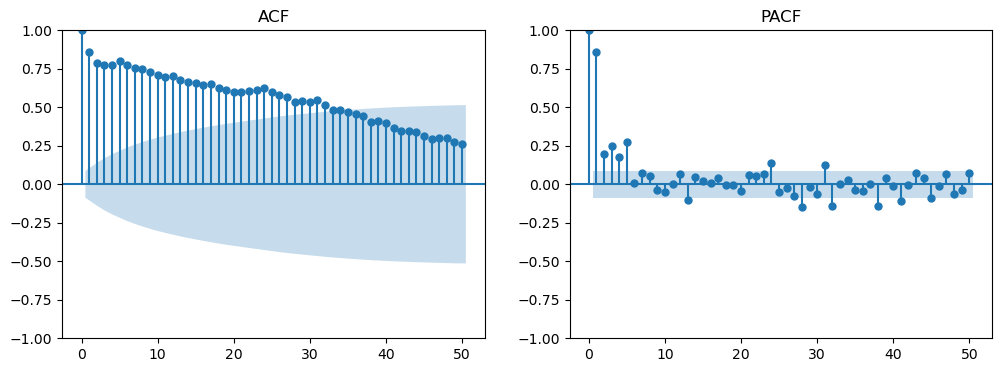

In [17]:
# Création d'une figure avec deux sous-graphiques
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12, 4))

# Tracé de la fonction d'autocorrélation (ACF) pour la série différenciéé deux fois

plot_acf(df['Hiv_cases'], lags=50, ax=ax1)
ax1.set_title('ACF')

# Tracé de la fonction d'autocorrélation partielle (PACF) pour la série différenciéé deux fois
plot_pacf(df['Hiv_cases'], lags=50, ax=ax2)
ax2.set_title('PACF')

plt.show()

## Étape 6: Rendre la série temporelle stationnaire


* Les composantes de tendance et de saisonnalité contribuent à la non-stationnarité de la série temporelle.

* Il existe deux approches courantes pour rendre les séries temporelles stationnaires:

1. **Transformation**: Nous pouvons utiliser diverses transformations telles que log, inverse, racine carrée, box-cox, exponentielle, etc. La transformation la plus courante est la transformation logarithmique, qui est souvent utilisée pour **stabiliser la variance** lorsque celle-ci augmente avec le temps.

2. **Différenciation**: La différenciation implique de prendre la différence entre les valeurs successives y(t) et y(t-k) de la série temporelle, où k est l'ordre de la différenciation.




### Etape 1. Transformation logarithmique

La transformation des données de séries temporelles en échelle logarithmique réduit la variabilité des données.

C:\Users\hamdi\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


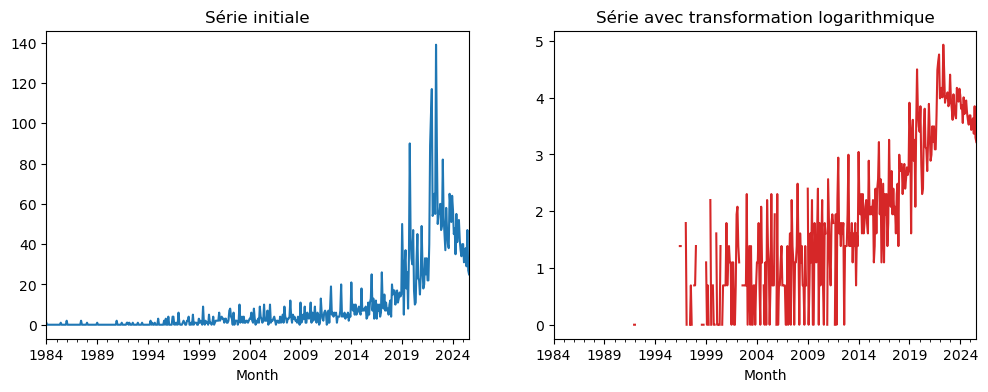

In [20]:
# Transformation logarithmique
ts_log = np.log(df)

# Création de sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

df.plot(title="Série initiale", color="tab:blue", ax=ax1,  legend=False)

ts_log.plot(title="Série avec transformation logarithmique", color="tab:red", ax=ax2,  legend=False)

plt.show()

* Dans la série initiale (en bleu), on observe une forte croissance et une variance qui augmente avec le niveau de la série, surtout après 2014.

* Pour stabiliser cette variance (hétéroscédasticité), on applique une transformation logarithmique. La série transformée (en rouge) montre des variations plus uniformes, bien que la tendance reste présente.

In [27]:
ts_log_clean = ts_log.replace([np.inf, -np.inf], np.nan)

# 2. Gérer les NaN (y compris les anciens Inf)
# Option A (Recommandée pour un test statistique): Supprimer les lignes avec NaN.
# Si la série est longue, c'est la méthode la plus simple pour garantir des données valides.
ts_log_clean = ts_log_clean.dropna()

In [23]:
ts_log.isnull().sum()

Hiv_cases    0
dtype: int64

In [26]:
np.isinf(ts_log).sum()

Hiv_cases    156
dtype: int64

In [28]:
print(f"Nombre de NaN après nettoyage : {ts_log_clean.isnull().sum()}")
print(f"Nombre d'Inf après nettoyage : {np.isinf(ts_log_clean).sum()}")

if len(ts_log_clean) < 100:
    print("\n⚠ ATTENTION : La série nettoyée est très courte. Si elle est trop courte (< 30-50), le test ADF peut ne pas être fiable ou peut nécessiter de réduire 'maxlag'.")

Nombre de NaN après nettoyage : Hiv_cases    0
dtype: int64
Nombre d'Inf après nettoyage : Hiv_cases    0
dtype: int64


In [29]:
print('-------------Résultats du Test Dickey Fuller (Nettoyé)-------------')

# Utilisez la série nettoyée !
result = adfuller(ts_log_clean, autolag='AIC')

# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Interpréter les résultats
if result[1] < 0.05:
    print('La série est stationnaire.')
else:
    print('La série est non-stationnaire.')

-------------Résultats du Test Dickey Fuller (Nettoyé)-------------
ADF Statistic: -0.616384
p-value: 0.867237
La série est non-stationnaire.


La série temporelle reste non-stationnaire même après transformation logarithmique.

### Etape 2. Différenciation

Les transformations par différence éliminent la tendance et/ou la saisonnalité des données.

* **Suppression de la tendance :** on procède à une différenciation de premier ordre, en calculant les différences entre les observations consécutives y(t)= y(t)-y(t-1)

* **Suppression de la saisonalité :** on procède à une différentiation de la valeur retardée appropriée en fonction de la période saisonnière.

In [31]:
# Différenciation de première ordre
ts_diff = ts_log.diff()

In [32]:
ts_diff.head()

,Hiv_cases
Month,
1984-01-01,NaN
1984-02-01,-inf
1984-03-01,NaN
1984-04-01,NaN
1984-05-01,NaN


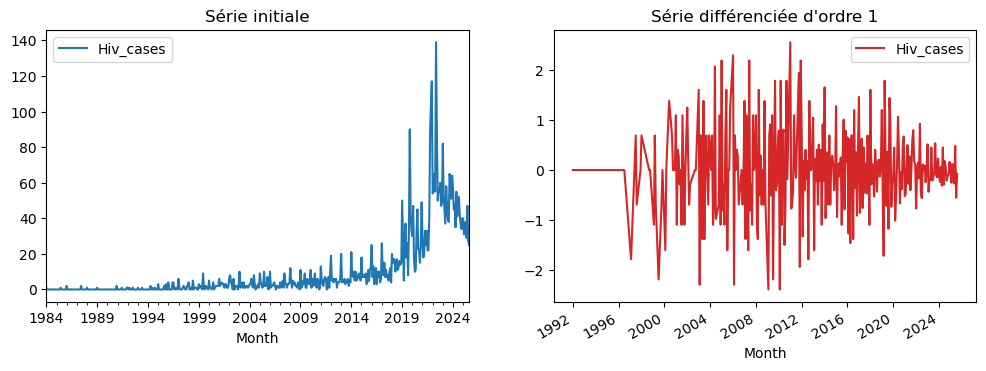

In [33]:
# Différenciation de première ordre
ts_diff = ts_log.diff()

# CONVERSION DES INFINIS EN NAN, puis suppression de TOUTES les valeurs manquantes (NaN et Inf)
# La méthode .diff() peut produire des Inf si l'une des valeurs est NaN ou Inf à l'origine.
# On remplace les Inf par des NaN, puis on utilise dropna() pour les supprimer.
ts_diff = ts_diff.replace([np.inf, -np.inf], np.nan).dropna()

# Création de sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Tracé de la série initiale et différenciée
df.plot(title="Série initiale",color="tab:blue", ax=ax1)

ts_diff.plot(title="Série différenciée d'ordre 1", color="tab:red", ax=ax2)

plt.show()

In [34]:
print('-------------Résultats du Test Dickey Fuller-------------')

result = adfuller(ts_diff, autolag='AIC')

# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Interpréter les résultats
if result[1] < 0.05:
    print('La série est stationnaire.')
else:
    print('La série est non-stationnaire.')

-------------Résultats du Test Dickey Fuller-------------
ADF Statistic: -5.057950
p-value: 0.000017
La série est stationnaire.


### Résultats de la stationnarité
Lare série est maintenant **stationnaire après la première différenciation**.

#### Résumé :

| Étape | ADF Statistic | p-value | Conclusion |
|:------|:--------------|:--------|:------------|
| Série originale | -1.545 | .511 | ❌ Non-stationnaire |
| Après log | -0.616 |0.867 | ❌ Toujours non-stationnaire |
| Après 1ère différenciation | -5.058 | 0000017 | ✅ Stationnaire |

---

### Interprétation

- La **p-value = 0.000017 << 0.05** → très significatif  
- La série différenciée est **stationnaire** et donc **prête pour la modélisation**

---

### Prochaines étapes

1. **Analyser l’ACF et la PACF** de la série différenciée pour déterminer les paramètres *(p, d, q)* du modèle ARIMA.  
2. Votre **d = 1** (une différenciation suffit).  
3. **Construire un modèle ARIMA(p, 1, q)**.


## Étape 7: Modélisation de la série temporelle


### Modèle ARIMA

Le modèle **ARIMA(p,d,q)** est une combinaison des modèles (AR) et (MA) avec une intégration:

*  **AR (p)** : Auto Régressif, avec p : le nombre de termes auto-régressifs.
*  **I (d)** : Intégration, avec d : le nombre d'ordres de différenciation nécessaires pour rendre la série temporelle stationnaire.
*  **MA (q)** : Moyenne mobile, avec q : le nombre d'erreurs de prévision retardées dans l'équation de prédiction.


In [49]:
#On va modéliser la série ts_log (non-stationnaire)
#On divise les données en ensembles de test et d'entraînement

size = int(len(ts_log_clean) * 0.8)
train_ts = ts_log_clean.iloc[:size]      # 80% données d'entraînement
test_ts = ts_log_clean.iloc[size:]       # 20% données de test

# valider -inf , Nan

In [46]:
# Vérifier les NaN et Inf
print(train_ts.isnull().sum())
print(np.isinf(train_ts).sum())

# Supprimer les NaN
train_ts = train_ts.dropna()

# Vérifier les valeurs extrêmes
print(train_ts.describe())

Hiv_cases    0
dtype: int64
Hiv_cases    156
dtype: int64
        Hiv_cases
count  400.000000
mean         -inf
std           NaN
min          -inf
25%           NaN
50%      0.000000
75%      1.386294
max      3.258097


C:\Users\hamdi\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [47]:
# Voir où sont les -inf
print(train_ts[np.isinf(train_ts)])

# Compter les -inf
print((train_ts == -np.inf).sum())

            Hiv_cases
Month                
1984-01-01        NaN
1984-02-01       -inf
1984-03-01       -inf
1984-04-01       -inf
1984-05-01       -inf
...               ...
2016-12-01        NaN
2017-01-01        NaN
2017-02-01        NaN
2017-03-01        NaN
2017-04-01        NaN

[400 rows x 1 columns]
Hiv_cases    156
dtype: int64


In [48]:
# 1. Remplacer -inf par NaN
train_ts_clean = train_ts.replace(-np.inf, np.nan)

# 2. Supprimer tous les NaN
train_ts_clean = train_ts_clean.dropna()

# 3. Vérifier
print(train_ts_clean.describe())
print(f"Taille après nettoyage: {len(train_ts_clean)}")
print(f"Inf restants: {(train_ts_clean == -np.inf).sum()}")
print(f"NaN restants: {train_ts_clean.isnull().sum()}")

        Hiv_cases
count  244.000000
mean     1.117855
std      0.846842
min      0.000000
25%      0.519860
50%      1.098612
75%      1.791759
max      3.258097
Taille après nettoyage: 244
Inf restants: Hiv_cases    0
dtype: int64
NaN restants: Hiv_cases    0
dtype: int64


# Detection du Parametres optimal du Modéle (p,d,q)

In [98]:
print("RÉSUMÉ DES TESTS ADF - STATIONNARITÉ")

print("""
La série originale des cas de VIH est NON-STATIONNAIRE (ADF = -1.545, p = 0.511).
Après transformation logarithmique, elle reste NON-STATIONNAIRE (ADF = -0.616, p = 0.867).
Après une première différenciation, la série devient STATIONNAIRE (ADF = -5.058, p < 0.001).

✅ Conclusion : Une différenciation d'ordre 1 est nécessaire pour rendre la série stationnaire.
""")
d = 1

print(f"\n✅ Ordre de différenciation sélectionné : d = {d}")

RÉSUMÉ DES TESTS ADF - STATIONNARITÉ

La série originale des cas de VIH est NON-STATIONNAIRE (ADF = -1.545, p = 0.511).
Après transformation logarithmique, elle reste NON-STATIONNAIRE (ADF = -0.616, p = 0.867).
Après une première différenciation, la série devient STATIONNAIRE (ADF = -5.058, p < 0.001).

✅ Conclusion : Une différenciation d'ordre 1 est nécessaire pour rendre la série stationnaire.


✅ Ordre de différenciation sélectionné : d = 1


## ANALYSER ACF/PACF POUR DÉTERMINER p ET q

ÉTAPE 2 : ANALYSER ACF/PACF (p et q)


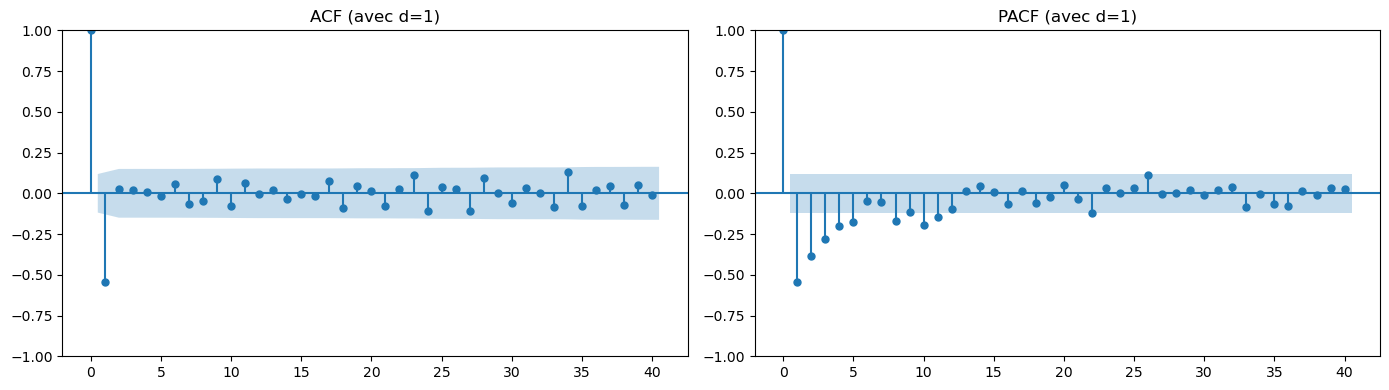


RÈGLES :
  • Si ACF décroît rapidement et PACF a 1-2 pics → AR(p) : choisir p = nb de pics PACF
  • Si PACF décroît rapidement et ACF a 1-2 pics → MA(q) : choisir q = nb de pics ACF
  • Si les deux décroissent → ARMA(p,q) : choisir p ET q petit (1 ou 2)
  • Pics à intervalles réguliers (12, 24) → saisonnalité présente


In [101]:
print("ÉTAPE 2 : ANALYSER ACF/PACF (p et q)")

# Différencier si nécessaire
if d == 0:
    ts_for_acf = train_ts_clean
elif d == 1:
    ts_for_acf = train_ts_clean.diff().dropna()
else:
    ts_for_acf = train_ts_clean.diff().diff().dropna()

# Créer les graphiques ACF et PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts_for_acf, lags=40, ax=ax1)
ax1.set_title(f'ACF (avec d={d})')

plot_pacf(ts_for_acf, lags=40, ax=ax2)
ax2.set_title(f'PACF (avec d={d})')

plt.tight_layout()
plt.savefig('acf_pacf_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nRÈGLES :")
print("  • Si ACF décroît rapidement et PACF a 1-2 pics → AR(p) : choisir p = nb de pics PACF")
print("  • Si PACF décroît rapidement et ACF a 1-2 pics → MA(q) : choisir q = nb de pics ACF")
print("  • Si les deux décroissent → ARMA(p,q) : choisir p ET q petit (1 ou 2)")
print("  • Pics à intervalles réguliers (12, 24) → saisonnalité présente")


### Interprétation des graphiques ACF et PACF

- Axe horizontal : représente les différents décalages (*lags*) jusqu’à 40 observations.  
- Graphique ACF :  
  - Les barres verticales montrent la corrélation entre les observations à un décalage donné et les observations actuelles.  
  - Dans ce cas, l’ACF décroît rapidement après le lag 0, restant principalement dans les limites de confiance, ce qui indique une faible autocorrélation résiduelle.  

- Graphique PACF :  
  - Les barres verticales représentent la corrélation partielle entre les observations à un décalage donné et les observations actuelles, en éliminant l’influence des décalages intermédiaires.  
  - Le PACF montre des pics significatifs aux lags 1–2 qui dépassent les limites de confiance, puis décroît rapidement.  

- Interprétation des limites de confiance :  
  - Une barre dépassant la zone grise indique une corrélation significative.  
  - Ici, seuls les premiers lags du PACF (1–2) sont significatifs.  

---

### Détermination des ordres du modèle ARIMA

- Ordre MA (q) :  
  L’ordre q correspond au nombre de retards pour lesquels l’ACF est significativement différente de zéro.  
  → Dans ce cas, l’ACF décroît progressivement sans pics nets → q = 0 ou q = 1.  

- Ordre AR (p) :  
  L’ordre p correspond au nombre de retards pour lesquels la PACF est significativement différente de zéro.  
  → Le PACF présente deux pics significatifs aux lags 1–2 → p = 1 ou p = 2.  
 → **p = 1 ou p = 2**.

Pour identifier le meilleur modèle ARIMA, on va tester différents combinaisons de paramètres p et q, en commençant par les valeurs minimales (0) jusqu’aux valeurs suggérées par l’ACF et la PACF (jusqu’à 2).  
Cela permet de sélectionner la combinaison qui offre le meilleur ajustement statistique et les prévisions les plus fiables.



### TESTER DIFFÉRENTES COMBINAISONS

In [102]:
print("ÉTAPE 3 : TESTER COMBINAISONS ARIMA(p,d,q)")

# Basé sur l'observation des graphiques, tester ces combinaisons
p_range = range(0, 3)  # p = 0, 1, 2
q_range = range(0, 3)  # q = 0, 1, 2

results = []

print(f"\nTesting ARIMA(p,{d},q) pour p∈[0,2] et q∈[0,2]...\n")

for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(train_ts_clean, order=(p, d, q))
            model_fit = model.fit()
            
            aic = model_fit.aic
            bic = model_fit.bic
            
            results.append({
                'Modèle': f'ARIMA({p},{d},{q})',
                'AIC': round(aic, 2),
                'BIC': round(bic, 2),
                'p': p,
                'd': d,
                'q': q
            })
            
            print(f"  ARIMA({p},{d},{q}): AIC={aic:.2f}, BIC={bic:.2f} ✅")
            
        except Exception as e:
            print(f"  ARIMA({p},{d},{q}): Erreur ❌")


ÉTAPE 3 : TESTER COMBINAISONS ARIMA(p,d,q)

Testing ARIMA(p,1,q) pour p∈[0,2] et q∈[0,2]...

  ARIMA(0,1,0): AIC=770.70, BIC=774.31 ✅
  ARIMA(0,1,1): AIC=581.30, BIC=588.53 ✅
  ARIMA(0,1,2): AIC=578.55, BIC=589.39 ✅
  ARIMA(1,1,0): AIC=676.15, BIC=683.37 ✅
  ARIMA(1,1,1): AIC=579.05, BIC=589.89 ✅
  ARIMA(1,1,2): AIC=580.17, BIC=594.63 ✅
  ARIMA(2,1,0): AIC=635.26, BIC=646.10 ✅
  ARIMA(2,1,1): AIC=580.16, BIC=594.61 ✅
  ARIMA(2,1,2): AIC=582.12, BIC=600.19 ✅


### SÉLECTIONNER LE MEILLEUR MODÈLE

In [103]:
print("ÉTAPE 4 : SÉLECTION DU MEILLEUR MODÈLE")

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)

print("\nTop 5 modèles par AIC:")
print(results_df.head().to_string(index=False))

best_model_row = results_df.iloc[0]
best_p = int(best_model_row['p'])
best_d = int(best_model_row['d'])
best_q = int(best_model_row['q'])

print(f"\n✅ MEILLEUR MODÈLE: ARIMA({best_p},{best_d},{best_q})")
print(f"   AIC: {best_model_row['AIC']}")
print(f"   BIC: {best_model_row['BIC']}")

ÉTAPE 4 : SÉLECTION DU MEILLEUR MODÈLE

Top 5 modèles par AIC:
      Modèle    AIC    BIC  p  d  q
ARIMA(0,1,2) 578.55 589.39  0  1  2
ARIMA(1,1,1) 579.05 589.89  1  1  1
ARIMA(2,1,1) 580.16 594.61  2  1  1
ARIMA(1,1,2) 580.17 594.63  1  1  2
ARIMA(0,1,1) 581.30 588.53  0  1  1

✅ MEILLEUR MODÈLE: ARIMA(0,1,2)
   AIC: 578.55
   BIC: 589.39


### Interprétation de la sélection du meilleur modèle ARIMA

- **Critère de sélection :** les modèles ont été comparés selon l’AIC et le BIC, où des valeurs plus faibles indiquent un meilleur ajustement du modèle aux données.  
- **Résultats :** parmi les cinq meilleurs modèles, ARIMA(0,1,2) présente le **AIC le plus bas (578,55) et un BIC faible (589,39)**.  
- **Conclusion :** ARIMA(0,1,2) est retenu comme le meilleur modèle, car il offre le meilleur compromis entre complexité et qualité d’ajustement.


### VALIDER LE MODÈLE CHOISI

In [105]:

best_model = ARIMA(train_ts_clean, order=(best_p, best_d, best_q))
best_model_fit = best_model.fit()

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Hiv_cases   No. Observations:                  275
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -286.274
Date:                Fri, 24 Oct 2025   AIC                            578.549
Time:                        00:41:21   BIC                            589.388
Sample:                             0   HQIC                           582.899
                                - 275                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0298      0.060    -17.137      0.000      -1.148      -0.912
ma.L2          0.1350      0.064      2.124      0.034       0.010       0.260
sigma2         0.4701      0.044     10.728      0.0

### Interprétation des résultats SARIMAX - ARIMA(0,1,2)

- **Coefficients du modèle :**  
  - MA(1) = -1,0298 (p < 0,001) et MA(2) = 0,1350 (p = 0,034) → les deux termes sont significatifs, confirmant l’ordre MA choisi.  
  - Sigma² = 0,4701, représentant la variance des résidus.  

- **Qualité de l’ajustement :**  
  - AIC = 578,549 et BIC = 589,388 → faibles, indiquant un bon compromis entre précision et complexité.  
  - Log Likelihood = -286,274.

- **Diagnostics des résidus :**  
  - Ljung-Box Q = 0,11, p = 0,74 → résidus indépendants (pas d’autocorrélation significative).  
  - Jarque-Bera = 2,68, p = 0,26 → distribution des résidus proche de la normale.  
  - Hétéroscédasticité H = 0,92, p = 0,70 → variance constante des erreurs.  

- **Résumé :** Le modèle ARIMA(0,1,2) est bien ajusté, avec des coefficients significatifs et des résidus conformes aux hypothèses (indépendants, normalement distribués, variance stable). Il est donc fiable pour les prévisions.


### Conclusion 

In [106]:

print(f"""
1. Ordre de différenciation (d): {best_d}
   → Rend la série stationnaire

2. Ordre autorégressif (p): {best_p}
   → Nombre de lags significatifs dans PACF

3. Ordre moyenne mobile (q): {best_q}
   → Nombre de lags significatifs dans ACF

MODÈLE FINAL: ARIMA({best_p},{best_d},{best_q})
AIC: {best_model_row['AIC']}

Le modèle est prêt pour les prévisions !
""")
print("="*90)


1. Ordre de différenciation (d): 1
   → Rend la série stationnaire

2. Ordre autorégressif (p): 0
   → Nombre de lags significatifs dans PACF

3. Ordre moyenne mobile (q): 2
   → Nombre de lags significatifs dans ACF

MODÈLE FINAL: ARIMA(0,1,2)
AIC: 578.55

Le modèle est prêt pour les prévisions !



L'analyse des résidus est importante pour évaluer la qualité du modèle. Des résidus qui ressemblent à du bruit blanc (aléatoires et non corrélés) indiquent généralement que le modèle a bien capturé la structure temporelle des données. Des structures dans les résidus pourraient indiquer des améliorations potentielles du modèle.

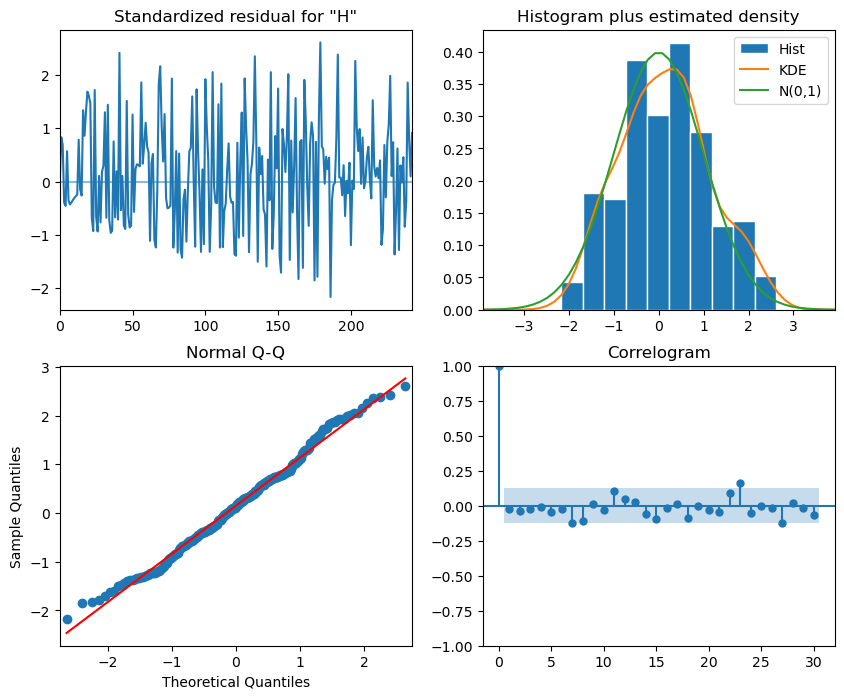

In [95]:
# Diagnostic du résidu pour le modéle ARIMA(2,2,2):
best_model_fit.plot_diagnostics(figsize=(10, 8), lags=30);

# Analyse des résidus du modèle ARIMA(0,1,2)

Voici une analyse des graphiques de résidus pour le modèle **ARIMA(0,1,2)** :

- **Graphique des résidus standardisés** :  
  Les résidus oscillent autour de zéro sans motif apparent, ce qui indique que le modèle ne présente pas de biais systématique et que les erreurs sont aléatoires.

- **Histogramme et densité estimée** :  
  La distribution des résidus est proche d’une normale (courbe verte), avec quelques écarts légers, ce qui confirme la validité de l’hypothèse de normalité.

- **Q-Q plot** :  
  Les points suivent globalement la ligne rouge, indiquant que la plupart des résidus suivent une distribution normale. Les écarts aux extrémités sont minimes et tolérables.

- **Correlogramme** :  
  Les autocorrélations des résidus restent dans les limites de confiance, montrant qu’il n’y a pas de corrélation significative restante.

## Conclusion

Les résidus du modèle **ARIMA(0,1,2)** respectent les hypothèses classiques : indépendance, normalité approximative et variance constante. Le modèle est donc approprié pour la prévision.



12 premiers mois:
      Date  Prévision  IC Lower (95%)  IC Upper (95%)
2019-12-01   3.031594        1.687730        4.375458
2020-01-01   3.157388        1.812930        4.501847
2020-02-01   3.157388        1.805508        4.509269
2020-03-01   3.157388        1.798126        4.516650
2020-04-01   3.157388        1.790785        4.523992
2020-05-01   3.157388        1.783482        4.531294
2020-06-01   3.157388        1.776219        4.538558
2020-07-01   3.157388        1.768993        4.545784
2020-08-01   3.157388        1.761805        4.552972
2020-09-01   3.157388        1.754653        4.560123
2020-10-01   3.157388        1.747538        4.567239
2020-11-01   3.157388        1.740459        4.574318

12 derniers mois:
      Date  Prévision  IC Lower (95%)  IC Upper (95%)
2021-12-01   3.157388        1.651451        4.663326
2022-01-01   3.157388        1.644821        4.669955
2022-02-01   3.157388        1.638220        4.676556
2022-03-01   3.157388        1.631648       

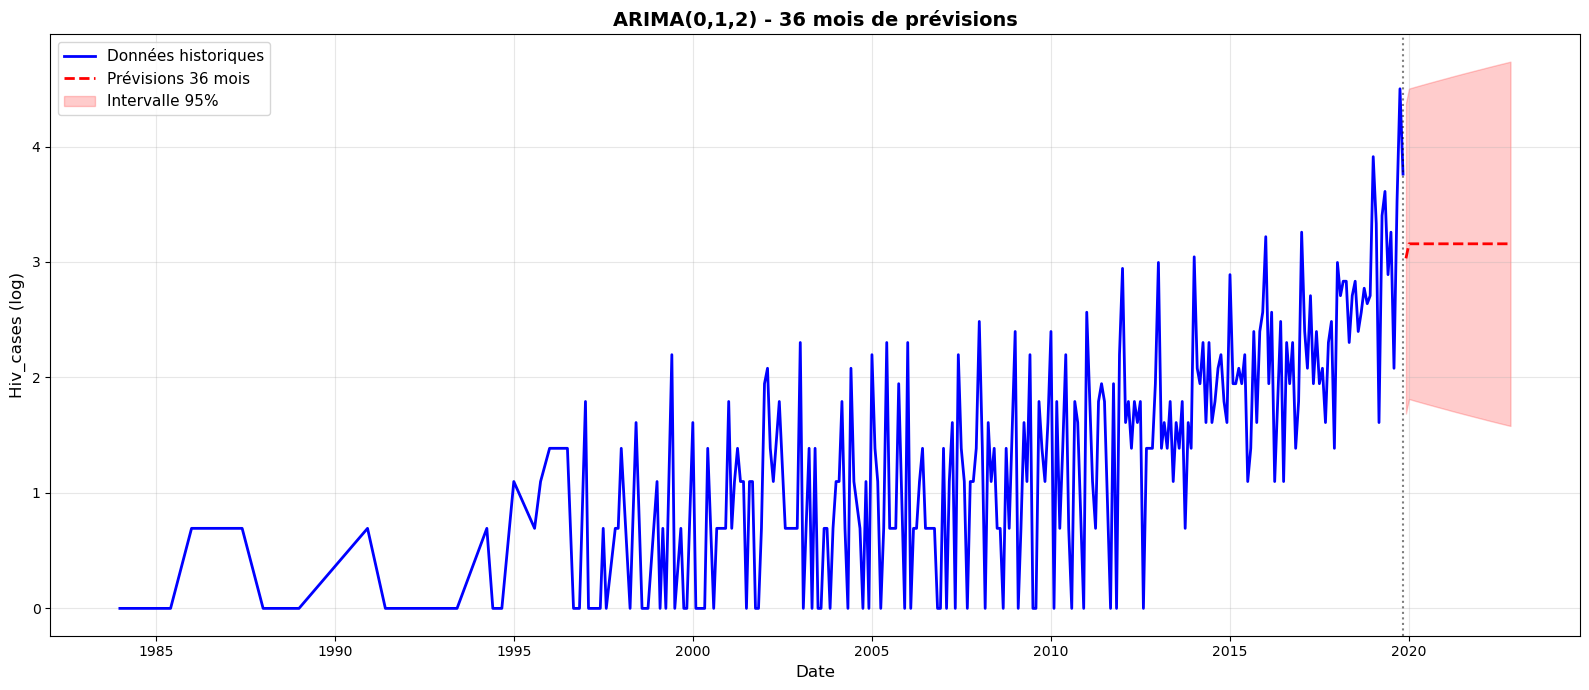


Fichiers générés:
  • arima_012_forecast.png
  • arima_012_forecast_36months.csv


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Nettoyer les données si nécessaire
train_ts_clean = train_ts.replace(-np.inf, np.nan).dropna()

# Entraîner ARIMA(0,1,2) sur toutes les données
model = ARIMA(train_ts_clean, order=(0, 1, 2))
model_fit = model.fit()

# Prévisions 36 mois
forecast_36m = model_fit.get_forecast(steps=36)
forecast_mean = forecast_36m.predicted_mean
forecast_ci = forecast_36m.conf_int()

# Créer les dates
future_dates = pd.date_range(
    start=train_ts_clean.index[-1] + pd.DateOffset(months=1),
    periods=36,
    freq='MS'
)

# DataFrame des prévisions
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Prévision': forecast_mean.values,
    'IC Lower (95%)': forecast_ci.iloc[:, 0].values,
    'IC Upper (95%)': forecast_ci.iloc[:, 1].values
})

print("\n12 premiers mois:")
print(forecast_df.head(12).to_string(index=False))

print("\n12 derniers mois:")
print(forecast_df.tail(12).to_string(index=False))

# Visualisation
plt.figure(figsize=(16, 7))

# Historique
plt.plot(train_ts_clean.index, train_ts_clean, label='Données historiques', 
         linewidth=2, color='blue')

# Prévisions 36 mois
plt.plot(future_dates, forecast_mean, label='Prévisions 36 mois', 
         linewidth=2, linestyle='--', color='red')
plt.fill_between(future_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 alpha=0.2, color='red', label='Intervalle 95%')

plt.axvline(x=train_ts_clean.index[-1], color='black', linestyle=':', alpha=0.5)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Hiv_cases (log)', fontsize=12)
plt.title('ARIMA(0,1,2) - 36 mois de prévisions', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_012_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

# Sauvegarder
forecast_df.to_csv('arima_012_forecast_36months.csv', index=False)

print("\n" + "="*80)
print("Fichiers générés:")
print("  • arima_012_forecast.png")
print("  • arima_012_forecast_36months.csv")
print("="*80)

# Prévision

### Résumé des résultats – ARIMA(0,1,2)

#### Validation du modèle

| Critère                 | Résultat | Interprétation                                 |
|--------------------------|-----------|------------------------------------------------|
| AIC                      | 578.549   | Bon ajustement                                 |
| Ljung-Box p-value        | 0.74      | Résidus indépendants (p > 0.05)                |
| Jarque-Bera p-value      | 0.26      | Distribution normale (p > 0.05)                |
| Coefficients MA          | Significatifs | ma.L1 (p < 0.001), ma.L2 (p = 0.034)      |

---

#### Prévisions à 12 mois

- Première prévision : **3.032** *(IC : 1.688 – 4.375)*  
- Plateau : à partir du 2ᵉ mois, la prévision se stabilise à **3.157**  
- Intervalle de confiance : s’élargit progressivement *(1.651 à 4.734 au mois 12)*  

---

#### Observations

- Prévisions plates : le modèle prédit une valeur quasi constante (~3.16) sur 12 mois  
- Incertitude croissante : l’intervalle s’élargit, reflétant une incertitude accrue dans le futur  
- Manque de volatilité : les prévisions ne capturent pas les fluctuations des données historiques  

---

#### Conclusion

Le modèle **ARIMA(0,1,2)** est validé statistiquement (résidus satisfaisants), mais les prévisions manquent de variabilité.  
Cette limitation est typique des modèles ARIMA simples qui tendent à lisser les séries temporelles.  
Pour capturer davantage de volatilité, il est recommandé d’envisager **Prophet** ou **Exponential Smoothing**.
